# EXPLORE AND VISUALIZATION DATA 

In [2]:
from datasets import load_dataset

d:\anaconda\envs\rag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds = load_dataset("ehovy/race", "middle")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

import hashlib
from collections import Counter
from transformers import AutoTokenizer

In [5]:
ds.column_names

{'test': ['example_id', 'article', 'answer', 'question', 'options'],
 'train': ['example_id', 'article', 'answer', 'question', 'options'],
 'validation': ['example_id', 'article', 'answer', 'question', 'options']}

In [6]:
ds['train'][0]

{'example_id': 'middle4558.txt',
 'article': '"I planted a seed. Finally grow fruits. Today is a great day. Pick off the star for you. Pick off the moon for you. Let it rise for you every day. Become candles burning myself. Just light you up, hey!... You are my little little apple. How much I love you, still no enough."\nThis words are from the popular song You Are My Little Dear Apple. Bae Seul-Ki acted as the leading dancer in the MV of the song. She loves dancing. She became crazy about hip-hop when she was a school girl.\nBai Seul-Ki was born on September 27, 1986. She is a South Korean singer and dancer. She is 168cm tall. She loves cooking. Her favourite food is spicy and salty. She like pink and red most. There are five members in her family---father, mother, two younger brothers and herself. She isn\'t married.\nAfter her father and mother broke up, she lived with her mother and new daddy. She enjoys being alone.',
 'answer': 'B',
 'question': 'Bae Seul-Ki   _   in the MV of th

In [7]:
ds['train'][0]["article"]

'"I planted a seed. Finally grow fruits. Today is a great day. Pick off the star for you. Pick off the moon for you. Let it rise for you every day. Become candles burning myself. Just light you up, hey!... You are my little little apple. How much I love you, still no enough."\nThis words are from the popular song You Are My Little Dear Apple. Bae Seul-Ki acted as the leading dancer in the MV of the song. She loves dancing. She became crazy about hip-hop when she was a school girl.\nBai Seul-Ki was born on September 27, 1986. She is a South Korean singer and dancer. She is 168cm tall. She loves cooking. Her favourite food is spicy and salty. She like pink and red most. There are five members in her family---father, mother, two younger brothers and herself. She isn\'t married.\nAfter her father and mother broke up, she lived with her mother and new daddy. She enjoys being alone.'

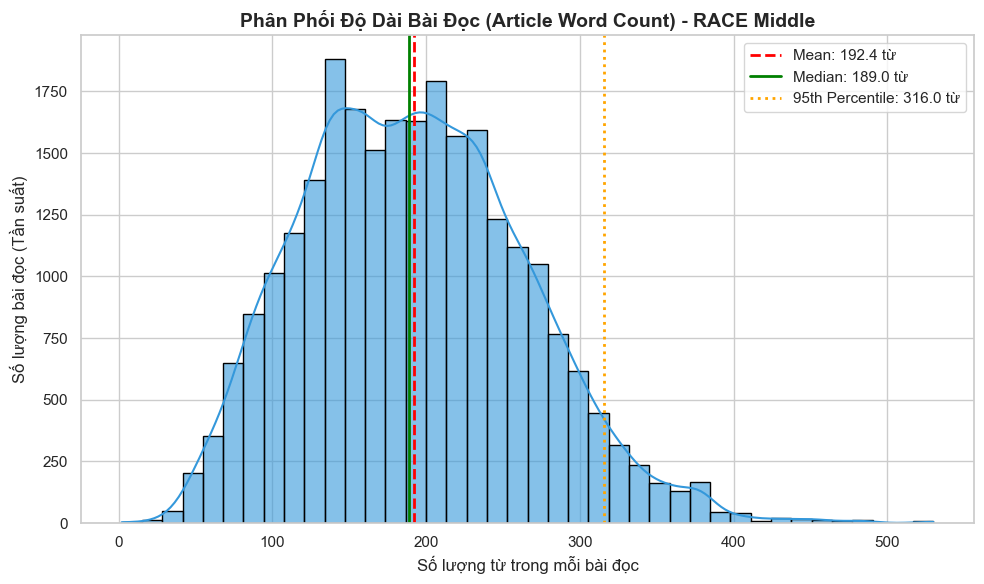

In [11]:
word_counts = [len(item["article"].split()) for item in ds['train']]

mean_val = np.mean(word_counts)
median_val = np.median(word_counts)
p95_val = np.percentile(word_counts, 95)

# histogram
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


sns.histplot(
    word_counts,
    bins=40,
    kde=True,
    color="#3498db",
    edgecolor="black",
    alpha=0.6,
)

plt.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_val:.1f} từ",
)
plt.axvline(
    median_val,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_val:.1f} từ",
)
plt.axvline(
    p95_val,
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"95th Percentile: {p95_val:.1f} từ",
)

plt.title(
    "Phân Phối Độ Dài Bài Đọc (Article Word Count) - RACE Middle",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Số lượng từ trong mỗi bài đọc", fontsize=12)
plt.ylabel("Số lượng bài đọc (Tần suất)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

Số đoạn văn trung bình trên mỗi bài: 5.1
Bài có số đoạn ít nhất: 1 | Nhiều nhất: 58
Phân vị thứ 50 (Median): 4
Phân vị thứ 95: 11


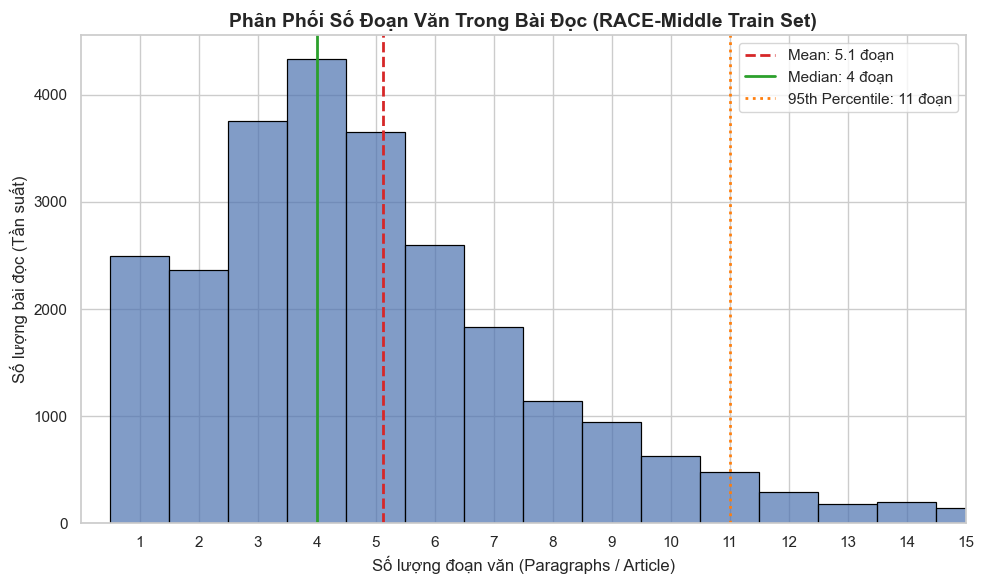

In [13]:
# 1. Tính số đoạn văn cho từng bài đọc
num_paragraphs = [len(item["article"].split("\n")) for item in ds["train"]]

# 2. Tính toán các chỉ số thống kê
mean_p = np.mean(num_paragraphs)
median_p = np.median(num_paragraphs)
p95_p = np.percentile(num_paragraphs, 95)
min_p = np.min(num_paragraphs)
max_p = np.max(num_paragraphs)

print(f"Số đoạn văn trung bình trên mỗi bài: {mean_p:.1f}")
print(f"Bài có số đoạn ít nhất: {min_p} | Nhiều nhất: {max_p}")
print(f"Phân vị thứ 50 (Median): {median_p:.0f}")
print(f"Phân vị thứ 95: {p95_p:.0f}")

# 3. Thiết lập biểu đồ Histogram
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Sử dụng bins tương ứng với các giá trị nguyên rời rạc
bins = np.arange(min_p, max_p + 2) - 0.5

sns.histplot(
    num_paragraphs,
    bins=bins,
    kde=False,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.7,
)

# 4. Thêm các đường mốc thống kê quan trọng
plt.axvline(
    mean_p,
    color="#D62728",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_p:.1f} đoạn",
)
plt.axvline(
    median_p,
    color="#2CA02C",
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_p:.0f} đoạn",
)
plt.axvline(
    p95_p,
    color="#FF7F0E",
    linestyle=":",
    linewidth=2,
    label=f"95th Percentile: {p95_p:.0f} đoạn",
)

# Căn chỉnh tiêu đề và các trục
plt.title(
    "Phân Phối Số Đoạn Văn Trong Bài Đọc (RACE-Middle Train Set)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Số lượng đoạn văn (Paragraphs / Article)", fontsize=12)
plt.ylabel("Số lượng bài đọc (Tần suất)", fontsize=12)
plt.xticks(np.arange(min_p, min(max_p + 1, 20)))
plt.xlim(0, max(p95_p + 3, 15))
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

[Article] Mean: 15.7 | Median: 15 | 95th: 26
[Paragraph] Mean: 3.3 | Median: 3 | 95th: 8


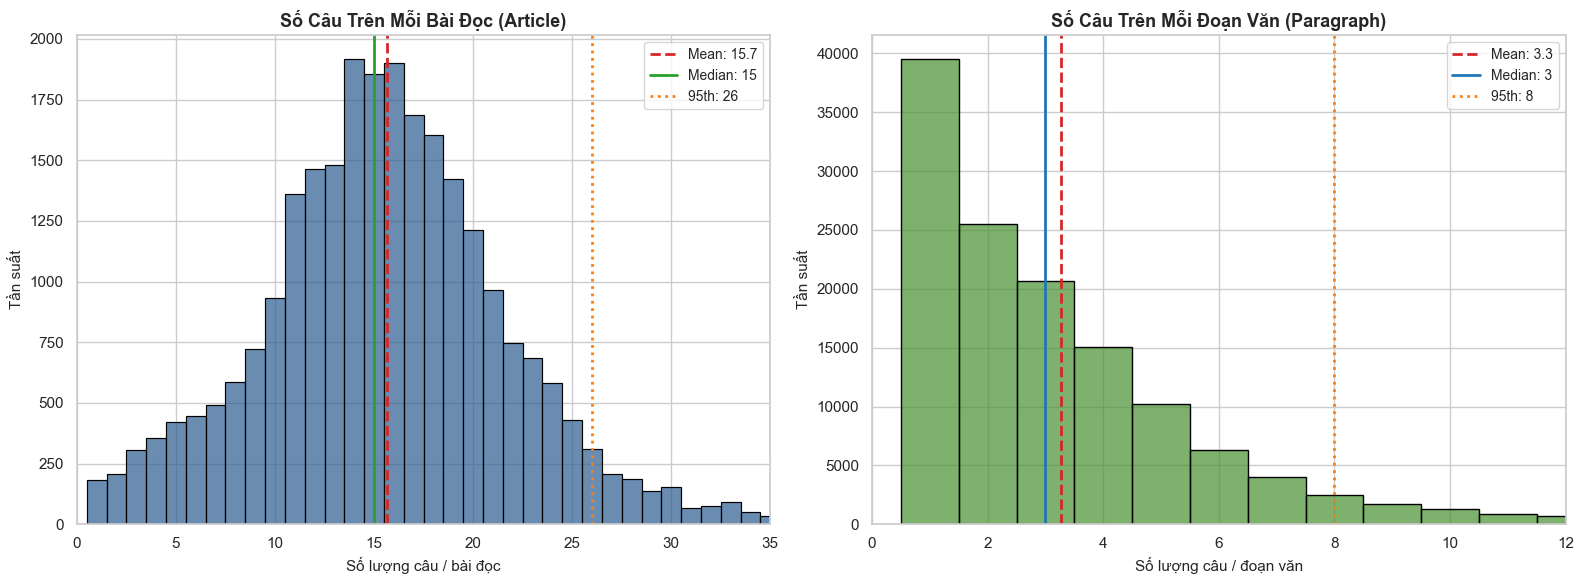

In [ ]:
# import re
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns

# Khởi tạo bộ tách câu (dùng nltk punkt hoặc regex)
try:
    import nltk

    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)
    from nltk.tokenize import sent_tokenize

    split_sentences = sent_tokenize
except Exception:
    # Regex fallback chuẩn cho tiếng Anh nếu không dùng nltk
    split_sentences = lambda text: [
        s.strip()
        for s in re.split(r"(?<=[.!?])\s+", text)
        if len(s.strip()) > 0
    ]

# 1. Thu thập số câu cho mỗi Article và mỗi Paragraph
sentences_per_article = []
sentences_per_paragraph = []

for item in ds["train"]:
    article_text = item["article"]

    # Đếm số câu trên toàn bài đọc
    article_sents = split_sentences(article_text)
    sentences_per_article.append(len(article_sents))

    # Tách theo từng đoạn văn (newline) và đếm số câu trong mỗi đoạn
    paragraphs = [p.strip() for p in article_text.split("\n") if p.strip()]
    for p in paragraphs:
        p_sents = split_sentences(p)
        if len(p_sents) > 0:
            sentences_per_paragraph.append(len(p_sents))

# 2. Tính toán các chỉ số thống kê
stats_article = {
    "mean": np.mean(sentences_per_article),
    "median": np.median(sentences_per_article),
    "p95": np.percentile(sentences_per_article, 95),
    "min": np.min(sentences_per_article),
    "max": np.max(sentences_per_article),
}

stats_paragraph = {
    "mean": np.mean(sentences_per_paragraph),
    "median": np.median(sentences_per_paragraph),
    "p95": np.percentile(sentences_per_paragraph, 95),
    "min": np.min(sentences_per_paragraph),
    "max": np.max(sentences_per_paragraph),
}

print(
    f"[Article] Mean: {stats_article['mean']:.1f} | Median: {stats_article['median']:.0f} | 95th: {stats_article['p95']:.0f}"
)
print(
    f"[Paragraph] Mean: {stats_paragraph['mean']:.1f} | Median: {stats_paragraph['median']:.0f} | 95th: {stats_paragraph['p95']:.0f}"
)

# 3. Vẽ 2 biểu đồ trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Số câu trên mỗi Article
bins_art = (
    np.arange(stats_article["min"], min(stats_article["max"] + 2, 45)) - 0.5
)
sns.histplot(
    sentences_per_article,
    bins=bins_art,
    color="#2b5c8f",
    edgecolor="black",
    alpha=0.7,
    ax=axes[0],
)
axes[0].axvline(
    stats_article["mean"],
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {stats_article['mean']:.1f}",
)
axes[0].axvline(
    stats_article["median"],
    color="#2ca02c",
    linestyle="-",
    linewidth=2,
    label=f"Median: {stats_article['median']:.0f}",
)
axes[0].axvline(
    stats_article["p95"],
    color="#ff7f0e",
    linestyle=":",
    linewidth=2,
    label=f"95th: {stats_article['p95']:.0f}",
)
axes[0].set_title(
    "Số Câu Trên Mỗi Bài Đọc (Article)", fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("Số lượng câu / bài đọc", fontsize=11)
axes[0].set_ylabel("Tần suất", fontsize=11)
axes[0].set_xlim(0, max(stats_article["p95"] + 5, 35))
axes[0].legend(fontsize=10)

# Biểu đồ 2: Số câu trên mỗi Paragraph
bins_para = (
    np.arange(stats_paragraph["min"], min(stats_paragraph["max"] + 2, 20)) - 0.5
)
sns.histplot(
    sentences_per_paragraph,
    bins=bins_para,
    color="#488f31",
    edgecolor="black",
    alpha=0.7,
    ax=axes[1],
)
axes[1].axvline(
    stats_paragraph["mean"],
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {stats_paragraph['mean']:.1f}",
)
axes[1].axvline(
    stats_paragraph["median"],
    color="#1f77b4",
    linestyle="-",
    linewidth=2,
    label=f"Median: {stats_paragraph['median']:.0f}",
)
axes[1].axvline(
    stats_paragraph["p95"],
    color="#ff7f0e",
    linestyle=":",
    linewidth=2,
    label=f"95th: {stats_paragraph['p95']:.0f}",
)
axes[1].set_title(
    "Số Câu Trên Mỗi Đoạn Văn (Paragraph)", fontsize=13, fontweight="bold"
)
axes[1].set_xlabel("Số lượng câu / đoạn văn", fontsize=11)
axes[1].set_ylabel("Tần suất", fontsize=11)
axes[1].set_xlim(0, max(stats_paragraph["p95"] + 3, 12))
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## train dataset comments

**Xét về cấu trúc Words - Articles và Paragraph - Articles**

Trung bình: 

    + Số word counts trung bình cho mỗi bài : 192.4 (từ)

    + Số dấu trung bình của các articles : 5.1 (đoạn)

Phân vị thứ 95 : 

    + word counts : 316 (từ)

    + dấu xuôngs dòng : 11 (đoạn)



Thể hiện được bài viết gồm các tương đối nhiều đoạn nhỏ, mỗi đoạn không quá nhiều từ.


**Xét về cấu trúc Sentences - Articles và Sentences - Paragraph**

[Article] Mean: 15.7 | Median: 15 | 95th: 26
[Paragraph] Mean: 3.3 | Median: 3 | 95th: 8




In [ ]:
# general statistic with test, val 

# chỉ dùng để tham chiếu với train, không chọn dựa trên test/val

In [4]:
raw_data = {}
subsets = ['middle', 'high']
splits = ['train', 'test', 'validation']

for sub in subsets : 
    raw_data[sub] = {}
    for sp in splits :
        raw_data[sub][sp] = load_dataset("ehovy/race", sub, split = sp)

In [4]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

In [5]:
# Hàm hash nội dung để kiểm tra trùng lặp và rò rỉ dữ liệu
def hash_text(text: str) -> str:
    cleaned = " ".join(text.strip().lower().split())
    return hashlib.md5(cleaned.encode("utf-8")).hexdigest()

In [6]:
# thong ke cau hoi/ bai doc duy nhat - tranh duplication
unique_articles = {}
for sub in subsets:
    unique_articles[sub] = {}
    for sp in splits:
        total_rows = len(raw_data[sub][sp])
        seen_hashes = set()
        for item in raw_data[sub][sp]:
            seen_hashes.add(hash_text(item["article"]))
        unique_count = len(seen_hashes)
        unique_articles[sub][sp] = seen_hashes
        ratio = total_rows / unique_count if unique_count > 0 else 0
        print(
            f"[{sub.upper()}-{sp.upper()}] Số dòng Q&A: {total_rows:,} | Số bài đọc duy nhất: {unique_count:,} (Lặp ~{ratio:.1f} câu hỏi/bài)"
        )

[MIDDLE-TRAIN] Số dòng Q&A: 25,421 | Số bài đọc duy nhất: 6,409 (Lặp ~4.0 câu hỏi/bài)
[MIDDLE-TEST] Số dòng Q&A: 1,436 | Số bài đọc duy nhất: 362 (Lặp ~4.0 câu hỏi/bài)
[MIDDLE-VALIDATION] Số dòng Q&A: 1,436 | Số bài đọc duy nhất: 368 (Lặp ~3.9 câu hỏi/bài)
[HIGH-TRAIN] Số dòng Q&A: 62,445 | Số bài đọc duy nhất: 18,724 (Lặp ~3.3 câu hỏi/bài)
[HIGH-TEST] Số dòng Q&A: 3,498 | Số bài đọc duy nhất: 1,045 (Lặp ~3.3 câu hỏi/bài)
[HIGH-VALIDATION] Số dòng Q&A: 3,451 | Số bài đọc duy nhất: 1,021 (Lặp ~3.4 câu hỏi/bài)


In [7]:
# kiem tra data leakage :

for sub in subsets:
    train_hashes = unique_articles[sub]["train"]
    val_hashes = unique_articles[sub]["validation"]
    test_hashes = unique_articles[sub]["test"]

    train_val_leak = train_hashes.intersection(val_hashes)
    train_test_leak = train_hashes.intersection(test_hashes)
    val_test_leak = val_hashes.intersection(test_hashes)

    print(f"[{sub.upper()}] Trùng lặp Train ∩ Val : {len(train_val_leak)} bài")
    print(f"[{sub.upper()}] Trùng lặp Train ∩ Test: {len(train_test_leak)} bài")
    print(f"[{sub.upper()}] Trùng lặp Val ∩ Test  : {len(val_test_leak)} bài")
    

[MIDDLE] Trùng lặp Train ∩ Val : 0 bài
[MIDDLE] Trùng lặp Train ∩ Test: 0 bài
[MIDDLE] Trùng lặp Val ∩ Test  : 0 bài
[HIGH] Trùng lặp Train ∩ Val : 0 bài
[HIGH] Trùng lặp Train ∩ Test: 0 bài
[HIGH] Trùng lặp Val ∩ Test  : 0 bài


In [8]:
# phan tich phan phoi token / dap an
stats_records = []

for sub in subsets:
    for sp in splits:
        ds = raw_data[sub][sp]
        ans_counter = Counter([item["answer"] for item in ds])
        total_ans = len(ds)

        # Đo độ dài token trên các bài đọc duy nhất (Unique Passages)
        seen_hashes = set()
        passage_token_lens = []
        passage_word_lens = []

        for item in ds:
            h = hash_text(item["article"])
            if h not in seen_hashes:
                seen_hashes.add(h)
                tokens = tokenizer.encode(item["article"], truncation=False)
                passage_token_lens.append(len(tokens))
                passage_word_lens.append(len(item["article"].split()))

        # Đo độ dài token cho câu hỏi (Question Token Length)
        question_token_lens = [
            len(tokenizer.encode(item["question"], truncation=False))
            for item in ds
        ]

        # Tỷ lệ bài đọc bị cắt cụt nếu không chunking (vượt max sequence 256)
        pct_truncated = (
            np.mean([t_len > 256 for t_len in passage_token_lens]) * 100
        )

        stats_records.append(
            {
                "subset": sub,
                "split": sp,
                "num_rows": total_ans,
                "num_unique_passages": len(passage_token_lens),
                "article_token_mean": np.mean(passage_token_lens),
                "article_token_median": np.median(passage_token_lens),
                "article_token_p95": np.percentile(passage_token_lens, 95),
                "article_truncated_pct": pct_truncated,
                "question_token_mean": np.mean(question_token_lens),
                "ans_A_pct": (ans_counter.get("A", 0) / total_ans) * 100,
                "ans_B_pct": (ans_counter.get("B", 0) / total_ans) * 100,
                "ans_C_pct": (ans_counter.get("C", 0) / total_ans) * 100,
                "ans_D_pct": (ans_counter.get("D", 0) / total_ans) * 100,
            }
        )

df_stats = pd.DataFrame(stats_records)
print(
    df_stats[
        [
            "subset",
            "split",
            "article_token_mean",
            "article_token_p95",
            "article_truncated_pct",
            "ans_A_pct",
            "ans_B_pct",
            "ans_C_pct",
            "ans_D_pct",
        ]
    ].to_string(index=False)
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (570 > 512). Running this sequence through the model will result in indexing errors


subset      split  article_token_mean  article_token_p95  article_truncated_pct  ans_A_pct  ans_B_pct  ans_C_pct  ans_D_pct
middle      train          246.696521             401.00              43.563738  21.419299  26.375831  27.559891  24.644979
middle       test          251.477901             411.00              46.408840  21.518106  27.019499  26.044568  25.417827
middle validation          245.304348             389.65              47.282609  21.657382  26.740947  26.880223  24.721448
  high      train          382.845546             544.00              93.089084  21.940908  25.656177  27.039795  25.363120
  high       test          377.110048             530.20              93.588517  21.555174  26.729560  27.158376  24.556890
  high validation          378.289912             524.00              91.968658  21.906694  26.282237  26.572008  25.239061


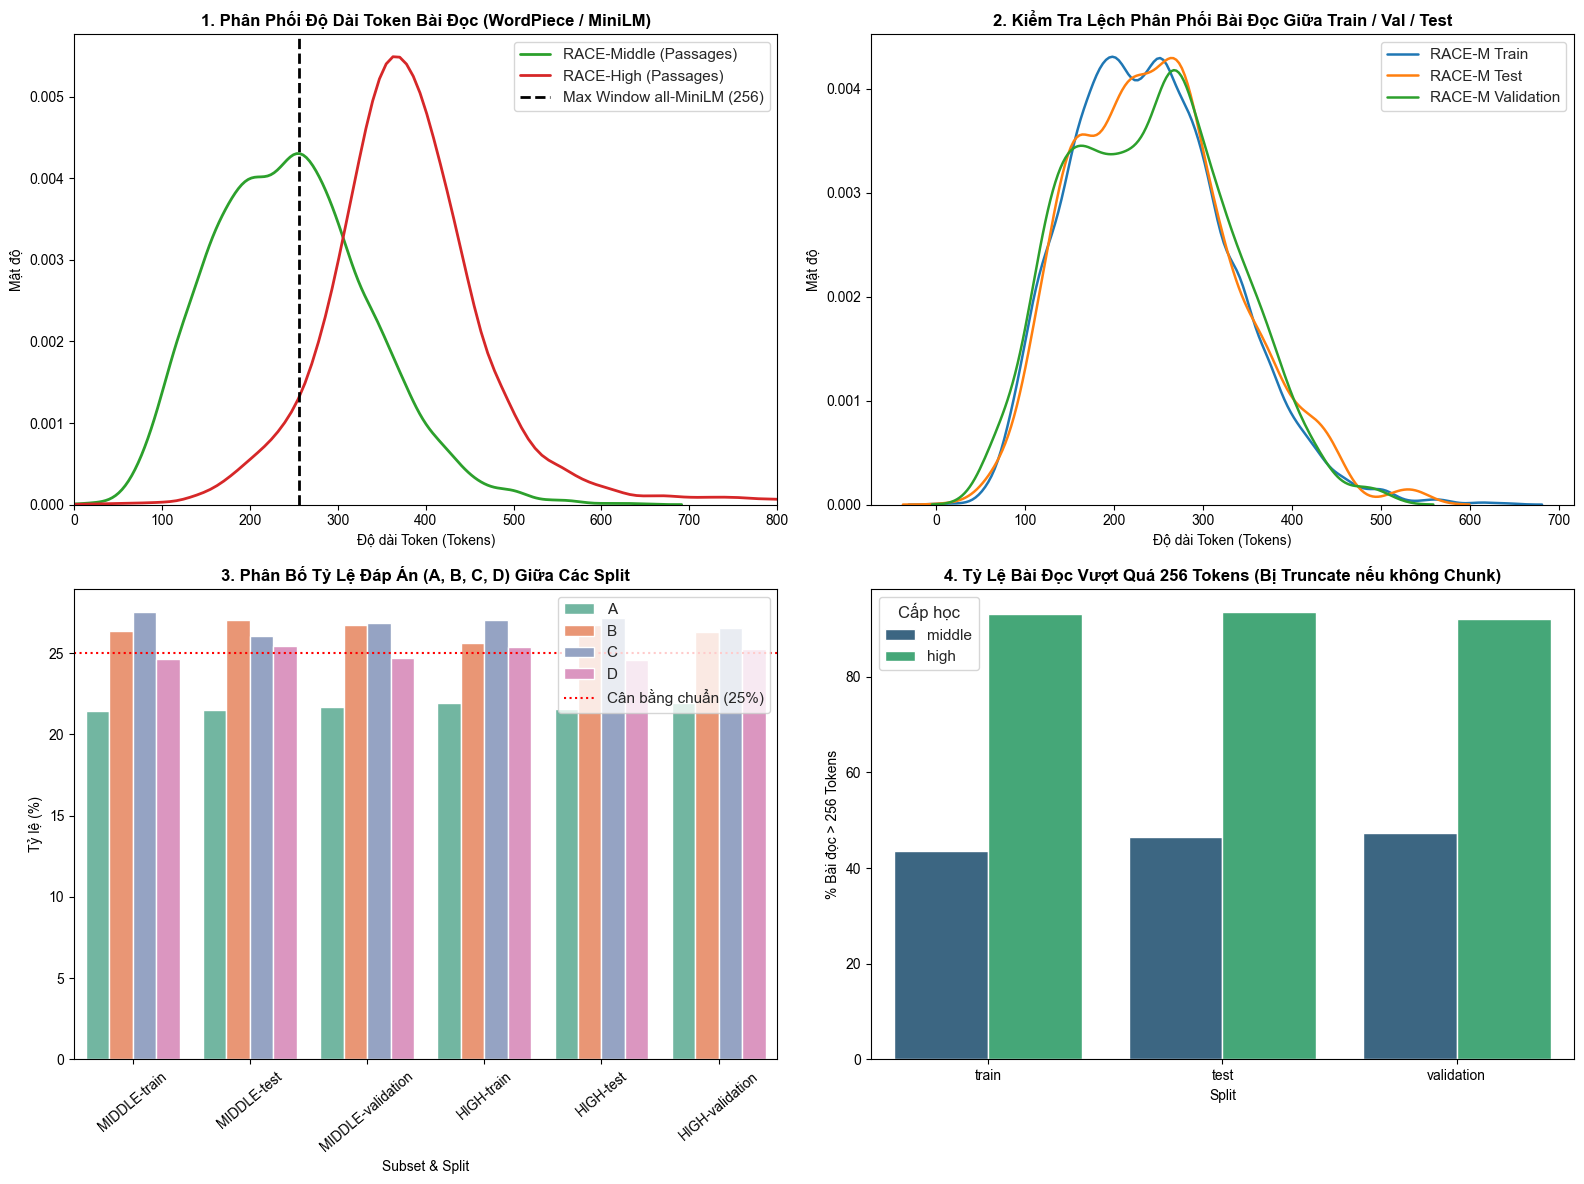

In [9]:
ig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Phân phối độ dài Token của bài đọc duy nhất (RACE-M vs RACE-H)
all_m_tokens = []
all_h_tokens = []
for sp in splits:
    seen = set()
    for item in raw_data["middle"][sp]:
        h = hash_text(item["article"])
        if h not in seen:
            seen.add(h)
            all_m_tokens.append(
                len(tokenizer.encode(item["article"], truncation=False))
            )
    seen = set()
    for item in raw_data["high"][sp]:
        h = hash_text(item["article"])
        if h not in seen:
            seen.add(h)
            all_h_tokens.append(
                len(tokenizer.encode(item["article"], truncation=False))
            )

sns.kdeplot(
    all_m_tokens,
    label="RACE-Middle (Passages)",
    color="#2ca02c",
    linewidth=2,
    ax=axes[0, 0],
)
sns.kdeplot(
    all_h_tokens,
    label="RACE-High (Passages)",
    color="#d62728",
    linewidth=2,
    ax=axes[0, 0],
)
axes[0, 0].axvline(
    256,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Max Window all-MiniLM (256)",
)
axes[0, 0].set_title(
    "1. Phân Phối Độ Dài Token Bài Đọc (WordPiece / MiniLM)",
    fontweight="bold",
    fontsize=12,
)
axes[0, 0].set_xlabel("Độ dài Token (Tokens)")
axes[0, 0].set_ylabel("Mật độ")
axes[0, 0].set_xlim(0, 800)
axes[0, 0].legend()

# Biểu đồ 2: So sánh độ dài bài đọc giữa Train, Dev và Test (Kiểm tra lệch phân phối)
for sp, color in zip(splits, ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    tokens_sp = [
        len(tokenizer.encode(item["article"], truncation=False))
        for item in raw_data["middle"][sp]
    ]
    sns.kdeplot(
        tokens_sp,
        label=f"RACE-M {sp.capitalize()}",
        color=color,
        linewidth=1.8,
        ax=axes[0, 1],
    )
axes[0, 1].set_title(
    "2. Kiểm Tra Lệch Phân Phối Bài Đọc Giữa Train / Val / Test",
    fontweight="bold",
    fontsize=12,
)
axes[0, 1].set_xlabel("Độ dài Token (Tokens)")
axes[0, 1].set_ylabel("Mật độ")
axes[0, 1].legend()

# Biểu đồ 3: Phân bố đáp án A/B/C/D qua các Split (Kiểm tra cân bằng lớp)
df_ans = df_stats.melt(
    id_vars=["subset", "split"],
    value_vars=["ans_A_pct", "ans_B_pct", "ans_C_pct", "ans_D_pct"],
    var_name="Option",
    value_name="Percentage",
)
df_ans["Option"] = df_ans["Option"].str.extract(r"ans_([A-D])_pct")
df_ans["Label"] = df_ans["subset"].str.upper() + "-" + df_ans["split"]

sns.barplot(
    data=df_ans,
    x="Label",
    y="Percentage",
    hue="Option",
    palette="Set2",
    ax=axes[1, 0],
)
axes[1, 0].axhline(25, color="red", linestyle=":", label="Cân bằng chuẩn (25%)")
axes[1, 0].set_title(
    "3. Phân Bố Tỷ Lệ Đáp Án (A, B, C, D) Giữa Các Split",
    fontweight="bold",
    fontsize=12,
)
axes[1, 0].set_xlabel("Subset & Split")
axes[1, 0].set_ylabel("Tỷ lệ (%)")
axes[1, 0].tick_params(axis="x", rotation=40)
axes[1, 0].legend(loc="upper right")

# Biểu đồ 4: Tỷ lệ phần trăm bài đọc bị cắt cụt (Truncation Risk)
trunc_df = df_stats[
    df_stats["split"] == "test"
]  # Minh họa trên test split của 2 tập
sns.barplot(
    data=df_stats,
    x="split",
    y="article_truncated_pct",
    hue="subset",
    palette="viridis",
    ax=axes[1, 1],
)
axes[1, 1].set_title(
    "4. Tỷ Lệ Bài Đọc Vượt Quá 256 Tokens (Bị Truncate nếu không Chunk)",
    fontweight="bold",
    fontsize=12,
)
axes[1, 1].set_xlabel("Split")
axes[1, 1].set_ylabel("% Bài đọc > 256 Tokens")
axes[1, 1].legend(title="Cấp học")

plt.tight_layout()
plt.show()

In [5]:
for sub in subsets: 
    for sp in splits:
        print(f"Example data samples of {sub}-{sp}:")
        for i in range(1,3):
            print(f"{1}. {raw_data[sub][sp][0]}")


Example data samples of middle-train:
1. {'example_id': 'middle4558.txt', 'article': '"I planted a seed. Finally grow fruits. Today is a great day. Pick off the star for you. Pick off the moon for you. Let it rise for you every day. Become candles burning myself. Just light you up, hey!... You are my little little apple. How much I love you, still no enough."\nThis words are from the popular song You Are My Little Dear Apple. Bae Seul-Ki acted as the leading dancer in the MV of the song. She loves dancing. She became crazy about hip-hop when she was a school girl.\nBai Seul-Ki was born on September 27, 1986. She is a South Korean singer and dancer. She is 168cm tall. She loves cooking. Her favourite food is spicy and salty. She like pink and red most. There are five members in her family---father, mother, two younger brothers and herself. She isn\'t married.\nAfter her father and mother broke up, she lived with her mother and new daddy. She enjoys being alone.', 'answer': 'B', 'questio

Nhận xét: 

- Đối với mỗi cấp, thì không có bài đọc trùng lặp. 
- Từ biểu đồ ta thấy được đa số dữ liệu đối với cấp HIGH thì các bài đọc tương đối dài vượt qua của model "all-MiniLM-L6-v2"
Do đó,chunking là 1 giải pháp giải quyết vấn đề này. 
- Ngoài ra, Đối với mỗi data sample cùng các bài đọc thì trùng lặp article. 

Phương pháp Chunking:Sentence Window với window 2-3.